<a href="https://colab.research.google.com/github/NadhaKaleel/northstar-analytics/blob/main/03_python_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  order_id customer_id service_type     order_created_at  promised_window_hours pickup_zone dropoff_zone priority_level  order_value booking_channel  special_handling_flag
0   O00001       C0292    Passenger  2024-08-20 14:43:00                      6     Airport        South         Medium       126.65             App                      0
1   O00002       C0459    Passenger  2024-05-14 22:16:00                     24       North      AIRPORT            Low       109.30             App                      0
2   O00003       C0161    Passenger  2025-09-02 14:37:00                      4        West      AIRPORT           High        33.50           Phone                      0
3   O00004       C0520       Parcel  2025-01-11 17:15:00                      2   RiverSide        North         Medium        10.04             App                      1
4   O00005       C0558       Retail  2025-02-17 19:32:00                     12   Riverside        SOUTH            Low       125.58        

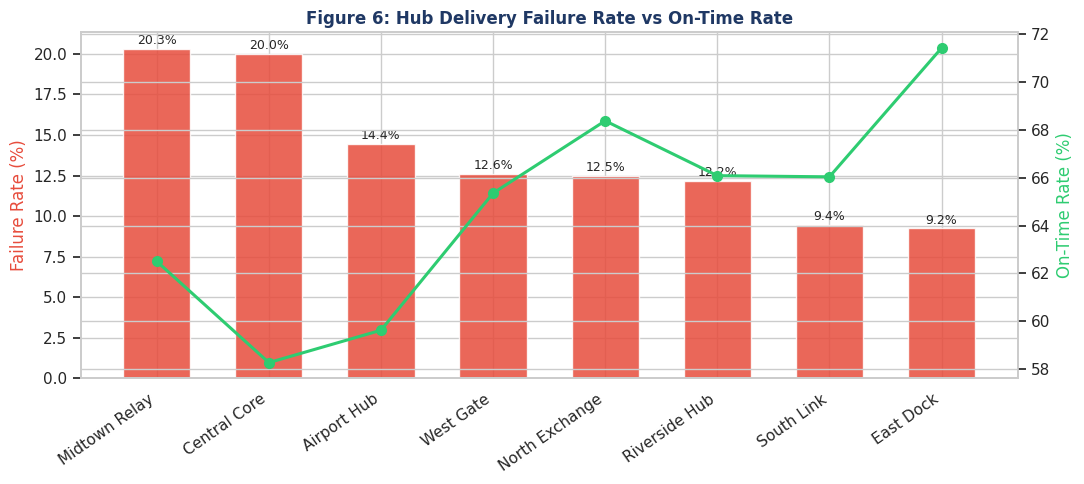

   incident_type  count  pct_high  avg_resolve  pct_escalated
    ProofMissing     46     39.13        10.77          10.87
  CustomerNoShow     44     36.36        13.89           9.09
  RouteDeviation     43     37.21        13.73          11.63
    VehicleFault     37     35.14         9.15           5.41
    BatteryAlert     36     27.78        11.71          13.89
    AppSyncError     31     22.58        12.66           9.68
TemperatureIssue     29     34.48        12.92          20.69
  SafetyNearMiss     14     35.71         9.67          35.71
   complaint_type  count  avg_res_days  avg_comp  pct_open  total_comp
            Delay    101          7.26     18.05     16.83     1696.84
     MissedPickup     64          7.64     22.59     18.75     1423.40
         AppIssue     53          8.60     19.61     15.09      980.72
  DriverBehaviour     51          8.16     21.15     17.65      973.06
SupportExperience     20          7.45     17.12     20.00      342.50
          Billin

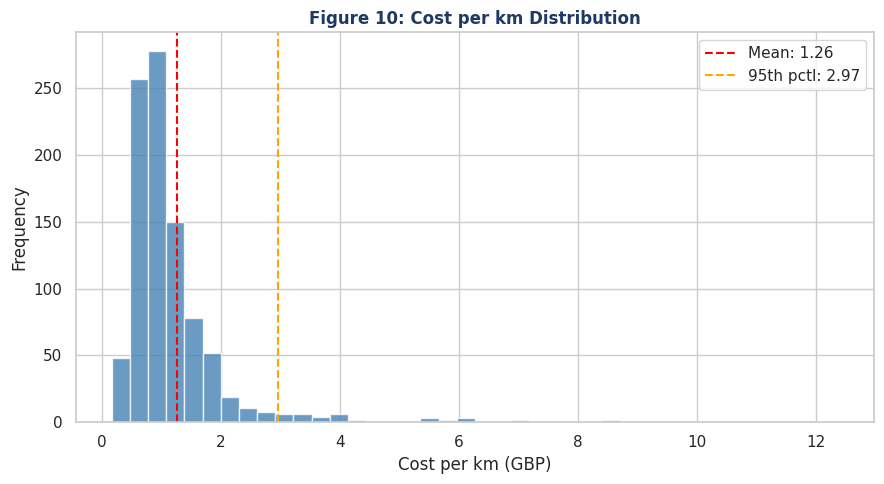

In [ ]:
# Install and import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

sns.set_theme(style='whitegrid', palette='muted')

# Load all datasets (manual upload version)
orders     = pd.read_csv('orders.csv')
deliveries = pd.read_csv('deliveries.csv')
customers  = pd.read_csv('customers.csv')
drivers    = pd.read_csv('drivers.csv')
vehicles   = pd.read_csv('vehicles.csv')
hubs       = pd.read_csv('hubs.csv')
incidents  = pd.read_csv('incidents.csv')
complaints = pd.read_csv('complaints.csv')
app_events = pd.read_csv('app_events.csv')

# Preview dataset
print(orders.head())

# Zone standardisation
def clean_zone(s): return s.str.strip().str.title()
for df,cols in [(orders,['pickup_zone','dropoff_zone']),(customers,['home_zone']),
               (drivers,['base_zone']),(vehicles,['assigned_zone']),
               (app_events,['zone_context'])]:
   for c in cols: df[c] = clean_zone(df[c])

# Datetime parsing
for col in ['dispatch_time','delivery_completed_at']:
   deliveries[col] = pd.to_datetime(deliveries[col], errors='coerce')
orders['order_created_at'] = pd.to_datetime(orders['order_created_at'], errors='coerce')
complaints['created_at']   = pd.to_datetime(complaints['created_at'], errors='coerce')

# Feature engineering
deliveries['delivery_duration_hrs'] = (
   deliveries['delivery_completed_at']-deliveries['dispatch_time']
).dt.total_seconds()/3600
deliveries['is_anomalous'] = deliveries['delivery_duration_hrs'] < 0
deliveries['cost_per_km']  = deliveries['fuel_or_charge_cost'] / deliveries['route_distance_km']
deliveries['is_failed']    = (deliveries['delivery_status']=='Failed').astype(int)

# Missing value report
for name,df in [('orders',orders),('deliveries',deliveries),
               ('complaints',complaints),('incidents',incidents),('app_events',app_events)]:
   m=df.isnull().sum(); m=m[m>0]
   if len(m): print(f'{name}: {dict(m)}')

   del_hub = deliveries.merge(hubs, on='hub_id', how='left')
hub_perf = del_hub.groupby(['hub_id','hub_name','zone']).agg(
   total=('delivery_id','count'),
   failed=('delivery_status',lambda x:(x=='Failed').sum()),
   on_time=('delivery_status',lambda x:(x=='OnTime').sum()),
   avg_rating=('customer_rating_post_delivery','mean'),
   avg_cost=('fuel_or_charge_cost','mean'),
   avg_overrides=('manual_route_override_count','mean')
).reset_index()
hub_perf['failure_rate'] = hub_perf['failed']/hub_perf['total']*100
hub_perf['ontime_rate']  = hub_perf['on_time']/hub_perf['total']*100
print(hub_perf.sort_values('failure_rate',ascending=False).round(2).to_string(index=False))

# Figure 6: dual-axis hub failure vs on-time rates
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
hp = hub_perf.sort_values('failure_rate',ascending=False)
x  = range(len(hp))
bars = ax1.bar(x, hp['failure_rate'], color='#E74C3C', alpha=0.85, width=0.6)
ax2.plot(x, hp['ontime_rate'],'o-',color='#2ECC71',linewidth=2.2,markersize=7)
ax1.set_xticks(x); ax1.set_xticklabels(hp['hub_name'],rotation=35,ha='right')
ax1.set_ylabel('Failure Rate (%)',color='#E74C3C')
ax2.set_ylabel('On-Time Rate (%)',color='#2ECC71')
ax1.set_title('Figure 6: Hub Delivery Failure Rate vs On-Time Rate',fontweight='bold',color='#1F3864')
for bar in bars: ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,
   f'{bar.get_height():.1f}%',ha='center',fontsize=9)
plt.tight_layout(); plt.savefig('hub_analysis.png',dpi=150); plt.show()

inc_type = incidents.groupby('incident_type').agg(
   count=('incident_id','count'),
   pct_high=('severity',lambda x:(x.isin(['High','Critical'])).mean()*100),
   avg_resolve=('resolved_hours','mean'),
   pct_escalated=('resolution_status',lambda x:(x=='Escalated').mean()*100)
).reset_index().sort_values('count',ascending=False)
print(inc_type.round(2).to_string(index=False))

comp_summary = complaints.groupby('complaint_type').agg(
   count=('complaint_id','count'),
   avg_res_days=('resolution_days','mean'),
   avg_comp=('compensation_amount','mean'),
   pct_open=('status',lambda x:(x=='Open').mean()*100),
   total_comp=('compensation_amount','sum')
).reset_index().sort_values('count',ascending=False)

print(comp_summary.round(2).to_string(index=False))
print(f"\nTotal compensation: GBP {complaints['compensation_amount'].sum():.2f}")
print(f"Open complaints: {(complaints.status=='Open').sum()}")

app_zone = app_events.groupby('zone_context').agg(
   total=('event_id','count'),
   success_rate=('success_flag','mean'),
   avg_latency=('api_latency_ms','mean'),
   p95_latency=('api_latency_ms',lambda x:np.percentile(x,95))
).reset_index()
app_zone['failure_rate_pct'] = (1-app_zone['success_rate'])*100
print(app_zone.round(2).to_string(index=False))

cost_km = deliveries['cost_per_km'].dropna().values

print('=== Cost-per-km Distribution (NumPy) ===')
print(f'Mean:       GBP {np.mean(cost_km):.3f}/km')
print(f'Median:     GBP {np.median(cost_km):.3f}/km')
print(f'Std Dev:    GBP {np.std(cost_km):.3f}/km')
print(f'90th pctl:  GBP {np.percentile(cost_km,90):.3f}/km')
print(f'95th pctl:  GBP {np.percentile(cost_km,95):.3f}/km')
print(f'IQR:        GBP {np.percentile(cost_km,75)-np.percentile(cost_km,25):.3f}/km')

threshold = np.percentile(cost_km,95)
outliers  = deliveries[deliveries['cost_per_km']>threshold]
print(f'\nHigh cost outliers (>{threshold:.2f} GBP/km): {len(outliers)} deliveries')
print(outliers[['delivery_id','delivery_status','route_distance_km',
               'fuel_or_charge_cost','cost_per_km']].head(8).round(3).to_string())

# Histogram with mean and 95th percentile markers
fig,ax=plt.subplots(figsize=(9,5))
ax.hist(cost_km,bins=40,color='steelblue',edgecolor='white',alpha=0.8)
ax.axvline(np.mean(cost_km),color='red',linestyle='--',linewidth=1.5,label=f'Mean: {np.mean(cost_km):.2f}')
ax.axvline(threshold,color='orange',linestyle='--',linewidth=1.5,label=f'95th pctl: {threshold:.2f}')
ax.set_title('Figure 10: Cost per km Distribution',fontweight='bold',color='#1F3864')
ax.set_xlabel('Cost per km (GBP)'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout(); plt.savefig('cost_dist.png',dpi=150); plt.show()